# Tutorial 06 — Atenção, conjuntos e informação de ordem

**Resoluções comentadas em português.** Material de estudo preparado com assistência de IA a partir de MM845 (Edward Hirst e Tomás S. R. Silva). Não é um gabarito oficial, nem um relato de execução no computador pessoal de Nina.

Os enunciados originais são preservados antes de cada solução. As saídas desta cópia são produzidas pela execução das células; os parâmetros e as sementes estão explícitos. As conclusões empíricas valem para esses experimentos, não como teoremas gerais.

[Mini-relatório](README.md) · [Material original](../../material_original/)

In [1]:
from pathlib import Path
import sys, os
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "estudos" / "comum.py").exists()), None)
if ROOT is None: raise RuntimeError("Abra este notebook dentro da pasta MM845-resolvido.")
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from estudos.comum import *
from IPython.display import display, Markdown
rng = np.random.default_rng(SEED + 6)
torch.manual_seed(SEED + 6)
OUT = ROOT / "estudos" / "tutorial_06" / "resultados"
OUT.mkdir(parents=True, exist_ok=True)
print("Semente:", SEED + 6, "| CPU | NumPy:", np.__version__, "| PyTorch:", torch.__version__)

Semente: 20260914 | CPU | NumPy: 2.3.5 | PyTorch: 2.10.0+cpu


## Dados, máscaras e divisão

As nuvens têm entre 10 e 22 pontos ruidosos em elipses aleatórias. O diâmetro é $\max_{i<j}\|x_i-x_j\|$; a distância média considera somente pares distintos. Guardamos os pontos em um tensor de tamanho máximo 22 **com máscara explícita**: padding não entra na soma, na média nem nas chaves da atenção. Isso permite minibatches sem alterar a matemática de conjuntos.

O treino de tarefas invariantes recebe permutações aleatórias, e o teste usa permutações independentes das mesmas nuvens. A ordenação angular é um pré-processamento por nuvem, sem consultar o rótulo. As normalizações do alvo são calculadas somente no treino. Os arquivos CSV registram MSE, parâmetros e invariância; não confundimos atenção recebida com explicação causal completa.

A implementação dos modelos está em [`../conjuntos.py`](../conjuntos.py).

In [2]:
from estudos.conjuntos import *
Xtr,dtr,mtr,atr,ptr=ellipse_clouds(1500,rng)
Xte,dte,mte,ate,pte=ellipse_clouds(400,rng)
Xtr_perm=reorder_clouds(Xtr,rng);Xte_perm=reorder_clouds(Xte,rng)
Xtr_sort=reorder_clouds(Xtr,angular=True);Xte_sort=reorder_clouds(Xte,angular=True)

def fit_set(kind,xx,yy,seed=32,epochs=65,layers=1,positional=False):
    torch.manual_seed(seed)
    model=(DeepSets() if kind=='DeepSets' else FlatSetMLP() if kind=='MLP' else
           SetAttention(layers=layers,positional=positional))
    mu=float(yy.mean());sd=max(float(yy.std()),1e-6)
    hist=train(model,xx,(yy-mu)/sd,epochs=epochs,lr=.002,batch_size=128,shuffle_seed=seed)
    model.target_mu=mu;model.target_sd=sd
    return model,hist

def set_predict(model,xx):return predict(model,xx)*model.target_sd+model.target_mu

## Exercício 1

> **Exercise 1 — how much structure do you actually need?**
> (a) Replace attention by **DeepSets**: embed each point with a shared MLP, sum
> over points, apply a head. That is permutation-invariant too, and has no
> $n\times n$ interaction. How close does it get on the diameter, and why might it
> struggle?
>
> (b) Sort the points (by angle, say) before feeding the MLP. Sorting is a cheap way
> to make a set canonical. Does it fix the MLP, and what has it cost you?
>
> (c) Change the label to the **mean pairwise distance** instead of the maximum. One
> of these tasks needs to identify a specific pair and one does not — which model's
> advantage shrinks?

### Resolução

**(a) DeepSets é suficiente em expressividade, não necessariamente em eficiência.** Para $F(X)=\rho(\sum_{x\in X}\phi(x))$, qualquer permutação deixa a soma inalterada. Um embedding suficientemente rico pode aproximar funções contínuas invariantes em domínios compactos com tamanho limitado; não existe uma impossibilidade geral de aproximar o diâmetro usando DeepSets. A dificuldade prática é comprimir em um vetor de dimensão fixa a informação relevante para um máximo entre pares. A atenção permite interações dependentes da entrada, mas também não garante identificar o par extremo. Comparamos MSE e número de parâmetros, sem assumir antecipadamente um vencedor.

**(b) Ordenar resolve a arbitrariedade da enumeração, não todas as simetrias.** Subtraímos o centroide para calcular o ângulo e ordenamos em $[-\pi,\pi)$. Com ângulos distintos, a representação resultante independe da ordem recebida. Empates precisam de desempate determinístico; a costura do ângulo, a rotação e mudanças na ordem radial podem tornar o mapa descontínuo. O custo é $O(n\log n)$, e a MLP continua presa ao limite de tamanho/padding escolhido. Mostramos o erro antes/depois de embaralhar: na MLP ordenada, é indispensável **reordenar novamente** a entrada de teste.

**(c) Distância média agrega todos os pares.** Ela não depende de um único par excepcional, mas continua sendo uma função de pares, e não simplesmente da média das coordenadas. Por exemplo, duas distribuições com mesmo centroide podem ter dispersões diferentes. O gargalo de compressão pode ficar menos exigente; medimos se a diferença de MSE diminui, usando também MSE normalizado pela variância do respectivo alvo para comparar tarefas em escalas diferentes. O resultado é empírico, não uma implicação lógica do objetivo.

         tarefa        modelo      MSE  MSE_normalizado  parametros  erro_permutacao
       diametro MLP sem ordem 0.021660         0.283909        8513     6.588349e-01
       diametro  MLP ordenada 0.009628         0.126204        8513     0.000000e+00
       diametro      DeepSets 0.009165         0.120134        2241     2.384186e-07
       diametro       Atenção 0.001019         0.013361       10849     2.384186e-07
distancia_media MLP sem ordem 0.002136         0.087015        8513     2.390596e-01
distancia_media  MLP ordenada 0.000196         0.007993        8513     0.000000e+00
distancia_media      DeepSets 0.001267         0.051618        2241     1.192093e-07
distancia_media       Atenção 0.000322         0.013114       10849     1.192093e-07


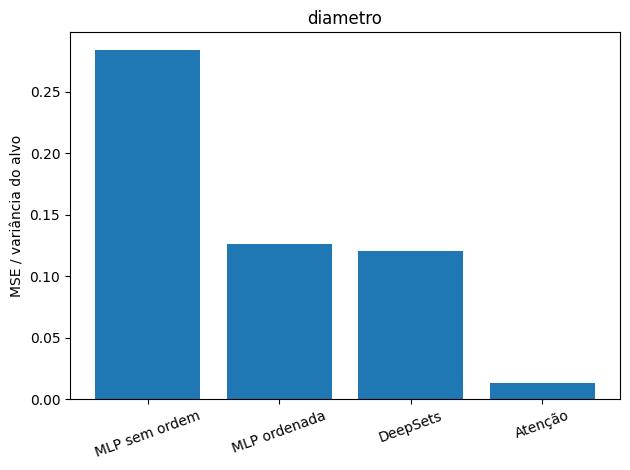

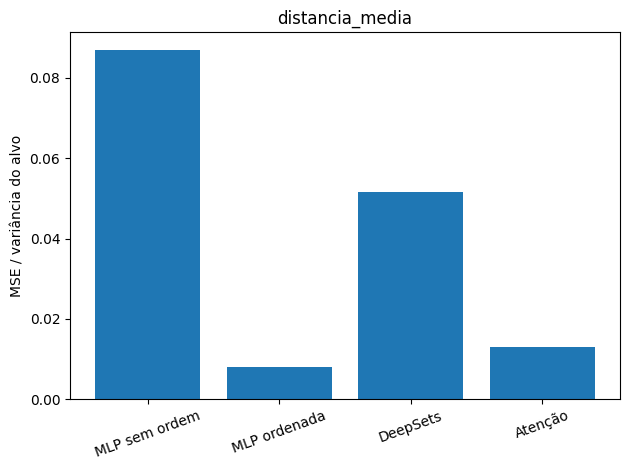

Diferença DeepSets−atenção (MSE normalizado): {'diametro': 0.10677298764669993, 'distancia_media': 0.038503875195298465}


In [3]:
rows=[];fitted={}
for target_name,ytrain,ytest in [('diametro',dtr,dte),('distancia_media',mtr,mte)]:
    for name,kind,tx,vx in [('MLP sem ordem','MLP',Xtr_perm,Xte_perm),
                            ('MLP ordenada','MLP',Xtr_sort,Xte_sort),
                            ('DeepSets','DeepSets',Xtr_perm,Xte_perm),
                            ('Atenção','Attention',Xtr_perm,Xte_perm)]:
        net,hist=fit_set(kind,tx,ytrain)
        fitted[(target_name,name)]=net
        err=mean_squared_error(ytest,set_predict(net,vx))
        shuffled=reorder_clouds(vx,rng)
        if name=='MLP ordenada':shuffled=reorder_clouds(shuffled,angular=True)
        inv=np.max(np.abs(set_predict(net,vx)-set_predict(net,shuffled)))
        if name in ['DeepSets','Atenção','MLP ordenada']:assert inv<2e-5
        rows.append(dict(tarefa=target_name,modelo=name,MSE=err,MSE_normalizado=err/np.var(ytest),
                         parametros=sum(p.numel() for p in net.parameters()),erro_permutacao=inv))
results=table(rows,'modelos_e_tarefas',OUT)
for task,df in results.groupby('tarefa'):
    plt.figure();plt.bar(df.modelo,df.MSE_normalizado);plt.xticks(rotation=20);plt.ylabel('MSE / variância do alvo')
    plt.title(task);figure('comparacao_'+task,OUT)
wide=results.pivot(index='tarefa',columns='modelo',values='MSE_normalizado')
print('Diferença DeepSets−atenção (MSE normalizado):', (wide['DeepSets']-wide['Atenção']).to_dict())

## Exercício 2

> **Exercise 2 — attention, tested rather than admired.**
> (a) **Ablation.** Zero out the attention a cloud pays to its two extreme points and
> measure how much the prediction changes; compare with zeroing two random points. If
> the extremes matter causally, the two should differ.
>
> (b) Train on the **mean** pairwise distance instead of the diameter and recompute
> the ratio above. A task with no special pair should show even less concentration —
> does it?
>
> (c) Add a second attention layer and re-measure. Does depth sharpen the attention
> onto the relevant pair, and does test error improve alongside it?

### Resolução

**(a) Intervenção, e o que ela mede.** Para cada nuvem identificamos o par de diâmetro e anulamos suas duas colunas na matriz de atenção, renormalizando cada linha sobre as chaves restantes. Fazemos a intervenção no modelo **já treinado**, mantendo pontos, consultas e conexões residuais. Comparamos $|\hat y_{\mathrm{abl}}-\hat y|$ e a mudança de MSE com retirar dois pontos uniformemente sorteados entre os não extremos, repetindo cinco sorteios. A comparação é pareada por nuvem. Ela mede o papel dessa via da atenção, não a remoção completa dos pontos: os extremos ainda passam pelo caminho residual. Uma atenção difusa ou uma rede insuficientemente treinada pode não apresentar contraste.

**(b) Atenção recebida.** Somamos a massa recebida de consultas válidas e calculamos a média por ponto extremo dividida pela média por ponto não extremo. A razão 1 é a referência difusa. Repetimos no modelo de distância média, mantendo como diagnóstico o par de diâmetro da mesma nuvem. A tarefa não privilegiar esse par não implica razão estritamente menor em toda inicialização.

**(c) Profundidade.** Treinamos duas camadas e reportamos a razão de cada camada separadamente, mais MSE fora da amostra. Uma segunda camada atende a representações já contextualizadas, de modo que a massa na posição de um extremo não é semanticamente idêntica à da primeira. Concentração maior e erro menor podem não ocorrer juntos; por isso os dois números ficam separados.

In [4]:
diam_net=fitted[('diametro','Atenção')]
mean_net=fitted[('distancia_media','Atenção')]
deep_net,_=fit_set('Attention',Xtr_perm,dtr,layers=2,epochs=65)
# Usamos a ordem original aqui para os índices de pares retornados na geração.
tx=torch.tensor(Xte);valid=tx[:,:,2]>0
extreme=torch.zeros_like(valid)
extreme[torch.arange(len(tx))[:,None],torch.tensor(pte)]=True

def attention_ratio(net):
    net.eval()
    with torch.no_grad():_,As=net(tx,return_attention=True)
    ratios=[]
    for layer,A in enumerate(As,1):
        received=(A*valid[:,:,None]).sum(1)/valid.sum(1,keepdim=True)
        e=(received*extreme).sum(1)/2
        other=(received*(valid&~extreme)).sum(1)/(valid.sum(1)-2)
        ratios.append(dict(camada=layer,razao_media=float((e/other.clamp_min(1e-10)).mean()),
                           razao_mediana=float((e/other.clamp_min(1e-10)).median())))
    return ratios

def ablated_prediction(net,mask):
    with torch.no_grad():p=net(tx,remove=mask).numpy().ravel()
    return p*net.target_sd+net.target_mu

base=set_predict(diam_net,Xte);abl=ablated_prediction(diam_net,extreme)
ablrows=[dict(intervencao='par extremo',repeticao=0,variacao_abs_media=np.mean(np.abs(abl-base)),
              aumento_MSE=mean_squared_error(dte,abl)-mean_squared_error(dte,base))]
for rep in range(5):
    remove=torch.zeros_like(valid)
    for i in range(len(tx)):
        choices=np.flatnonzero((valid[i]&~extreme[i]).numpy());ix=rng.choice(choices,2,replace=False);remove[i,ix]=True
    p=ablated_prediction(diam_net,remove)
    ablrows.append(dict(intervencao='dois não extremos',repeticao=rep,variacao_abs_media=np.mean(np.abs(p-base)),
                        aumento_MSE=mean_squared_error(dte,p)-mean_squared_error(dte,base)))
ablation=table(ablrows,'ablacao_atencao',OUT)
rat=[];performance=[]
for name,net,yy in [('diametro_1_camada',diam_net,dte),('media_1_camada',mean_net,mte),('diametro_2_camadas',deep_net,dte)]:
    for row in attention_ratio(net):rat.append(dict(modelo=name,**row))
    performance.append(dict(modelo=name,MSE=mean_squared_error(yy,set_predict(net,Xte))))
rat=table(rat,'razao_atencao_extremos',OUT)
performance=table(performance,'profundidade_e_erro',OUT)

      intervencao  repeticao  variacao_abs_media  aumento_MSE
      par extremo          0            0.056677     0.005582
dois não extremos          0            0.004388     0.000060
dois não extremos          1            0.004344     0.000091
dois não extremos          2            0.004378     0.000039
dois não extremos          3            0.003975     0.000041
dois não extremos          4            0.004436     0.000058
            modelo  camada  razao_media  razao_mediana
 diametro_1_camada       1    11.604004       5.743108
    media_1_camada       1     1.086316       1.088714
diametro_2_camadas       1     6.383005       4.431353
diametro_2_camadas       2   368.823853       9.228932
            modelo      MSE
 diametro_1_camada 0.001019
    media_1_camada 0.000322
diametro_2_camadas 0.000262


## Exercício 3

> **Exercise 3 — when order does matter.**
> Attention alone cannot see order, which is why transformers add positional
> encodings. Build a task where order carries the answer: treat each cloud as the
> vertex sequence of a closed polygon and predict its **signed area**
> $\frac12\sum_i (x_i y_{i+1} - x_{i+1} y_i)$, which changes sign if you reverse the
> traversal. Show that the set model cannot do better than chance on the sign, then
> switch on `positional=True` — the sinusoidal encoding of slide 5 is already built —
> and watch it become solvable. (On the diameter it buys nothing, as it should not.)

### Resolução

**Impossibilidade sem ordem.** Se $P=(x_1,\ldots,x_n)$ e $P^{\mathrm{rev}}$ é sua reversão, o conjunto é o mesmo, mas $A(P^{\mathrm{rev}})=-A(P)$. Um modelo invariante fornece uma única predição $c$ para ambos. Na dupla balanceada, o erro quadrático médio é
$$\frac{(c-A)^2+(c+A)^2}{2}=c^2+A^2\ge A^2,$$
minimizado por $c=0$. Para classificação de sinal, uma decisão determinística igual nas duas entradas acerta exatamente uma: 50%, quando $A\ne0$. Isso é um limite de informação, não falta de épocas.

**Experimento sem vazamento.** Primeiro separamos nuvens base de treino e teste; só então criamos as duas orientações em cada partição. Treinamos a mesma arquitetura com e sem posição sinusoidal e verificamos o erro de reversão, MSE e acurácia do sinal. A posição quebra a invariância que tornava a tarefa impossível, mas não garante que um treino finito atinja alta acurácia. Registramos o resultado obtido, sem substituí-lo pelo resultado desejado.

**Construção exata como controle.** Com acesso à sequência, a fórmula de shoelace implementada abaixo calcula a área exatamente. Isso mostra construtivamente a solucionabilidade da tarefa ordenada mesmo que a rede particular aprenda lentamente. Para o diâmetro, posição não fornece informação relevante: seu valor verdadeiro é invariante. Ela pode alterar a otimização/erro finito, e não há teorema de que as duas redes terão MSE idêntico.

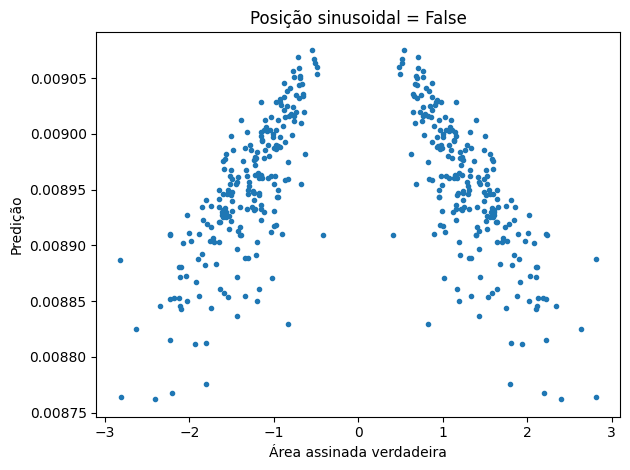

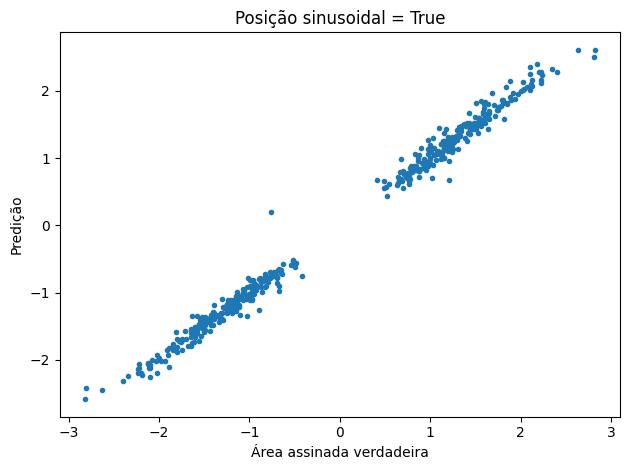

 posicao      MSE  acuracia_sinal  diferenca_max_reversao
   False 1.944902        0.500000            5.122274e-08
    True 0.014549        0.997727            5.198764e+00
Controle shoelace: erro máximo 3.2064342159188186e-07


Diâmetro: MSE sem posição 0.0010193103988240227 | com posição 0.002549809430768219 | sensibilidade à permutação com posição 0.093319535
Referência ótima invariante para área: MSE de predição zero 1.9448218003324005


In [5]:
# Duplas balanceadas; nuvens base diferentes em cada partição.
Xbase,_,_,Abase,_=ellipse_clouds(750,rng)
Xcheck,_,_,Acheck,_=ellipse_clouds(220,rng)
XO=np.concatenate([Xbase,reorder_clouds(Xbase,reverse=True)])
YO=np.concatenate([Abase,-Abase])
XT=np.concatenate([Xcheck,reorder_clouds(Xcheck,reverse=True)])
YT=np.concatenate([Acheck,-Acheck])
area_results=[]
for positional in [False,True]:
    net,hist=fit_set('Attention',XO,YO,seed=51,epochs=160,layers=2,positional=positional)
    pp=set_predict(net,XT)
    signacc=accuracy_score(YT>0,pp>=0)
    delta=np.max(np.abs(pp[:len(Xcheck)]-pp[len(Xcheck):]))
    if not positional:
        assert delta<2e-5
        assert abs(signacc-.5)<1e-12
    area_results.append(dict(posicao=positional,MSE=mean_squared_error(YT,pp),acuracia_sinal=signacc,
                              diferenca_max_reversao=delta))
    plt.figure();plt.scatter(YT,pp,s=9);plt.xlabel('Área assinada verdadeira');plt.ylabel('Predição')
    plt.title('Posição sinusoidal = '+str(positional));figure('area_posicao_'+str(positional),OUT)
area_results=table(area_results,'area_assinada_e_ordem',OUT)

def shoelace_packed(X):
    values=[]
    for cloud in X:
        n=int(cloud[:,2].sum());P=cloud[:n,:2]
        values.append(.5*np.sum(P[:,0]*np.roll(P[:,1],-1)-np.roll(P[:,0],-1)*P[:,1]))
    return np.array(values)
exact=shoelace_packed(XT)
# Os rótulos foram gerados antes da conversão para float32.
assert np.max(np.abs(exact-YT))<1e-6
print('Controle shoelace: erro máximo',np.max(np.abs(exact-YT)))
pos_diam,_=fit_set('Attention',Xtr_perm,dtr,epochs=65,positional=True)
perm_error=np.max(np.abs(set_predict(pos_diam,Xte)-set_predict(pos_diam,Xte_perm)))
print('Diâmetro: MSE sem posição',mean_squared_error(dte,set_predict(diam_net,Xte)),
      '| com posição',mean_squared_error(dte,set_predict(pos_diam,Xte)),
      '| sensibilidade à permutação com posição',perm_error)
print('Referência ótima invariante para área: MSE de predição zero',np.mean(YT**2))
write_summary(OUT.parent/'README.md',
 'comparar informação de conjunto, interações e ordem.',
 'permutação preserva diâmetro, mas elimina o sinal da área orientada.',
 'Treinei DeepSets, MLPs e atenção, ablatei extremos e comparei posições sinusoidais.',
 f'O modelo sem ordem ficou em 50% no sinal; com posição obteve {area_results.iloc[1].acuracia_sinal:.1%}.',
 'Ablacionar atenção não remove o caminho residual, e concentração não é causalidade completa.')